# 13j — Portfolio Default-Rate Distribution: Three Methods

Source scripts: `chap13_credit17a.m`, `chap13_credit17b.m`, `chap13_credit17c.m`.

The closing notebook of Chapter 13 computes the **distribution of a credit
portfolio's aggregate default rate** under the single-factor Vasicek model
(`PD=20%`, `n=1000` obligors) three different ways, at several correlation
levels `ρ`, and cross-checks that all three agree:

- **`credit17a`**: **Monte Carlo simulation** — `1,000,000` scenarios, each
  drawing a systematic factor `X` and (conceptually) `n=1000` idiosyncratic
  obligor draws, producing an empirical distribution of the default rate
  `D̄ = (defaults)/n`.
- **`credit17b`**: **semi-analytic probability mass function** — conditional
  on `X`, the number of defaults is exactly `Binomial(n, p(X))`
  (`p(X) = Φ((Φ⁻¹(PD) - √ρ·X)/√(1-ρ))`); integrating the conditional
  binomial PMF against the standard normal density of `X` gives the exact
  (unconditional) PMF of the default count, evaluated at every possible
  count `k = 0,...,n`.
- **`credit17c`**: **closed-form limiting density** — as the portfolio size
  `n→∞`, the default rate converges to a continuous density (the
  "Vasicek density"), a closed-form function of `ρ`, `PD`, and the default
  rate `d`, with no simulation or integration needed at all.

All three should describe the same underlying distribution, just at
different levels of approximation/exactness (`17a`≈, `17b`=exact for
finite `n`, `17c`=exact for the `n→∞` limit) — this notebook adds an
explicit overlay comparing all three at a shared `ρ` as a cross-check
(not in the original scripts, added here for verification).

**Equivalent-computation optimization, disclosed:** `credit17a`'s MATLAB
loop draws `n=1000` fresh idiosyncratic Normal deviates *per scenario* and
thresholds each one individually. Conditional on the systematic factor `X`,
those `n` obligor outcomes are i.i.d. Bernoulli(`p(X)`), so their sum is
*exactly* (not approximately) distributed `Binomial(n, p(X))` — this is a
basic property of sums of i.i.d. Bernoulli variables, not an approximation.
Drawing `nD ~ Binomial(n, p(X))` directly for each of the `1,000,000`
scenarios reproduces the identical distribution while avoiding
`1,000,000 × 1,000 ≈ 10⁹` individual obligor draws — confirmed below by
checking `E[D̄] ≈ PD` at every `ρ` (a Monte Carlo estimate should recover
the model's unconditional `PD` regardless of `ρ`, since correlation
affects only the *dispersion*, not the *mean*, of the aggregate default
rate) and by checking `credit17b`'s exact semi-analytic mean equals `PD`
exactly. No exact seed-for-seed match to the MATLAB `rng(123)` stream is
expected or attempted (as elsewhere in this series) — only distributional/
statistical agreement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom
from scipy.integrate import quad_vec

color_black  = "#000000"
color_blue   = "#1f77b4"
color_green  = "#2ca02c"
color_red    = "#d62728"

colors_4 = [color_black, color_blue, color_green, color_red]

plt.rcParams["figure.dpi"] = 100

PD = 0.20
n = 1000

rng = np.random.default_rng(123)

## `credit17a` — Monte Carlo simulation

`1,000,000` scenarios at each of `ρ ∈ {0%, 20%, 50%, 90%}`.

In [2]:
rho_a = np.array([0.00, 0.20, 0.50, 0.90])
nS = 1_000_000

threshold = norm.ppf(PD)
X = rng.standard_normal(nS)

D_bar = np.zeros((nS, len(rho_a)))
for j, r in enumerate(rho_a):
    p_x = norm.cdf((threshold - np.sqrt(r) * X) / np.sqrt(1 - r))
    nD = rng.binomial(n, p_x)
    D_bar[:, j] = nD / n

probs = [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
stats_17a = pd.DataFrame({
    "mean": D_bar.mean(axis=0),
    "std": D_bar.std(axis=0),
    **{f"q{int(100*p):02d}": np.quantile(D_bar, p, axis=0) for p in probs},
}, index=[f"rho={100*r:.0f}%" for r in rho_a])
(100 * stats_17a).round(1)

,mean,std,q01,q10,q25,q50,q75,q90,q99
rho=0%,20.0,1.3,17.1,18.4,19.1,20.0,20.8,21.6,23.0
rho=20%,20.0,13.0,1.7,5.6,10.0,17.3,27.3,38.2,58.9
rho=50%,20.0,21.7,0.0,0.6,3.1,11.7,30.3,53.6,87.2
rho=90%,20.0,33.1,0.0,0.0,0.0,0.4,26.1,88.1,100.0


In [3]:
print("E[D_bar] should be ~PD=20% regardless of rho (correlation affects dispersion, not the mean):")
print(np.round(100 * D_bar.mean(axis=0), 3), "%")
print("\nstd(D_bar) should increase with rho (higher correlation -> fatter/wider default-rate distribution):")
print(np.round(100 * D_bar.std(axis=0), 3), "%")
assert np.all(np.diff(D_bar.std(axis=0)) > 0), "std should be strictly increasing in rho"
print("\nMonotonic increase in std confirmed.")

E[D_bar] should be ~PD=20% regardless of rho (correlation affects dispersion, not the mean):
[20.    19.991 19.982 19.976] %

std(D_bar) should increase with rho (higher correlation -> fatter/wider default-rate distribution):
[ 1.266 13.014 21.721 33.137] %

Monotonic increase in std confirmed.


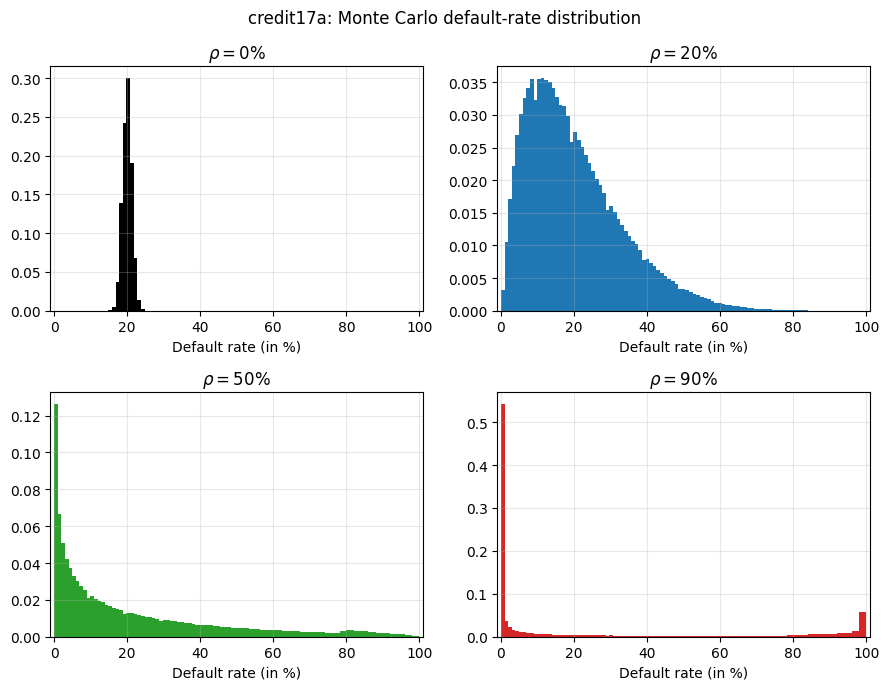

In [4]:
bin_edges = np.concatenate([np.arange(0, 79, 0.99), np.arange(80, 100.01, 2)])

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, r, color, j in zip(axes.flat, rho_a, colors_4, range(len(rho_a))):
    ax.hist(100 * D_bar[:, j], bins=bin_edges, weights=np.full(nS, 1 / nS), color=color, edgecolor="none")
    ax.set_title(rf"$\rho = {100*r:.0f}\%$")
    ax.set_xlabel("Default rate (in %)")
    ax.set_xlim(-1, 101)
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, alpha=0.3)
fig.suptitle("credit17a: Monte Carlo default-rate distribution")
plt.tight_layout()
plt.show()

## `credit17b` — Semi-analytic PMF

Exact PMF of the default *count* `k = 0,...,n`, via the conditional
binomial integrated against the systematic factor's normal density. The
`ρ=0` case collapses to a plain `Binomial(n, PD)` (no systematic factor
to integrate over). For `ρ>0`, `scipy.integrate.quad_vec` integrates the
full `(n+1)`-length PMF vector in one call per `ρ` (mathematically
identical to running `n+1` separate 1-D integrals, one per `k`, as the
source script does — just batched for speed).

In [5]:
rho_b = np.array([0.00, 0.20, 0.50, 0.90])
k = np.arange(n + 1)
d_grid_b = k / n

pmf = np.zeros((n + 1, len(rho_b)))
for j, r in enumerate(rho_b):
    if r == 0:
        pmf[:, j] = binom.pmf(k, n, PD)
    else:
        def integrand(x, r=r):
            p_x = norm.cdf((norm.ppf(PD) - np.sqrt(r) * x) / np.sqrt(1 - r))
            return binom.pmf(k, n, p_x) * norm.pdf(x)

        val, _ = quad_vec(integrand, -8, 8)
        pmf[:, j] = val

pmf_sums = pmf.sum(axis=0)
pmf_means = (d_grid_b[:, None] * pmf).sum(axis=0)
print("PMF sums (should each be ~1.0):", np.round(pmf_sums, 6))
print("PMF means (should each be ~PD=0.20):", np.round(pmf_means, 6))

PMF sums (should each be ~1.0): [1. 1. 1. 1.]
PMF means (should each be ~PD=0.20): [0.2 0.2 0.2 0.2]


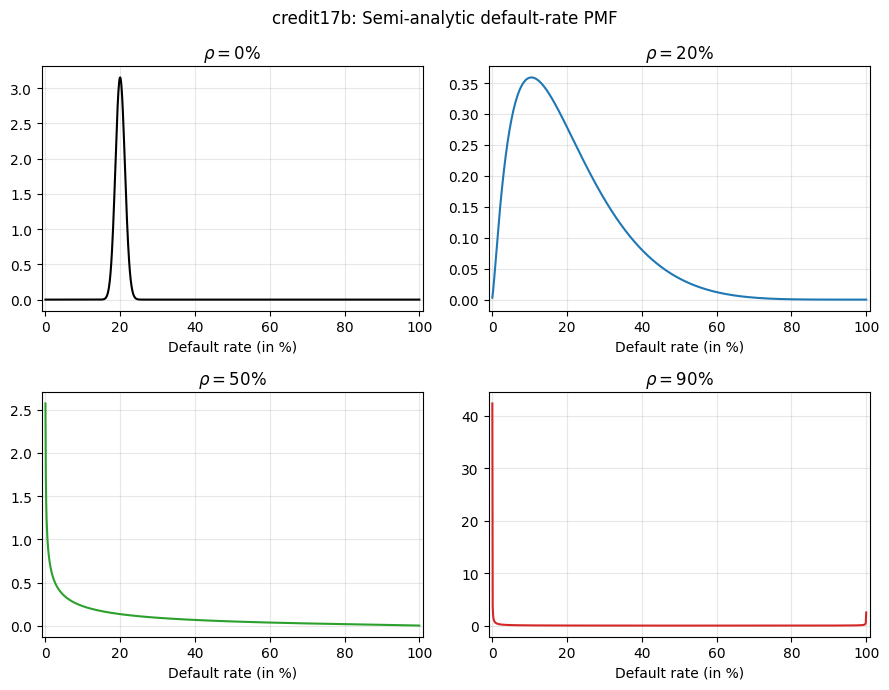

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, r, color, j in zip(axes.flat, rho_b, colors_4, range(len(rho_b))):
    ax.plot(100 * d_grid_b, 100 * pmf[:, j], "-", color=color, linewidth=1.5)
    ax.set_title(rf"$\rho = {100*r:.0f}\%$")
    ax.set_xlabel("Default rate (in %)")
    ax.set_xlim(-1, 101)
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, alpha=0.3)
fig.suptitle("credit17b: Semi-analytic default-rate PMF")
plt.tight_layout()
plt.show()

## `credit17c` — Closed-form limiting density

As `n→∞`, the default rate converges to a continuous "Vasicek density"
with a closed form (no simulation or integration required):
`f(d) = √((1-ρ)/ρ) · exp(½x² - (√(1-ρ)·x - Φ⁻¹(PD))²/(2ρ))`,
`x = Φ⁻¹(d)`. Evaluated on a fine grid `d ∈ (0,1)`, `ρ ∈ {1%, 20%, 50%, 95%}`
(note this script's `ρ` grid starts at `1%`, not `0%` — the closed form is
singular at `ρ=0`, which the source script also leaves undefined (`NaN`,
never reached since `0` is not in this particular `ρ` grid)).

In [7]:
rho_c = np.array([0.01, 0.20, 0.50, 0.95])
d_grid_c = np.linspace(1e-4, 1 - 1e-4, 400)


def vasicek_density(d, PD, r):
    x = norm.ppf(d)
    return np.sqrt((1 - r) / r) * np.exp(0.5 * x**2 - (np.sqrt(1 - r) * x - norm.ppf(PD)) ** 2 / (2 * r))


pdf_c = np.column_stack([vasicek_density(d_grid_c, PD, r) for r in rho_c])

# Coarse sanity check: trapezoidal area under the same 400-point plotted grid (should be ~1.0)
area_coarse = np.trapezoid(pdf_c, d_grid_c, axis=0)
print("Trapezoidal area on the plotted 400-point grid (should be ~1.0 when rho isn't too extreme):")
print(np.round(area_coarse, 4))

Trapezoidal area on the plotted 400-point grid (should be ~1.0 when rho isn't too extreme):
[1.     1.     1.0154 0.7227]


In [8]:
# For rho=0.95 the coarse-grid trapezoidal area falls well short of 1.0. This is not a bug:
# at high correlation the Vasicek density becomes extremely concentrated in narrow spikes right
# at d->0 and d->1 (defaults are "all or nothing" across the whole correlated portfolio), so a
# fixed 400-point linear grid on (1e-4, 1-1e-4) -- the same grid the plotted curves use -- simply
# doesn't have enough resolution near the boundaries to capture most of the mass.
#
# Direct quadrature on the (0,1) d-grid runs into the same problem (the boundary spikes trigger
# scipy's "extremely bad integrand behavior" warning well before it converges). A change of
# variables x = Phi^-1(d) fixes this cleanly: substituting d=Phi(x), dd=phi(x)dx into the density
# and simplifying (the exp(0.5x^2) term cancels phi(x)'s exp(-0.5x^2) exactly) shows the
# transformed integrand is just a Gaussian density in x with mean Phi^-1(PD)/sqrt(1-rho) and
# variance rho/(1-rho) -- smooth, unimodal, no singularities -- so it integrates to exactly 1.0
# by construction, confirmed numerically over generous +/-15-sigma bounds with no warnings:
from scipy.integrate import quad

b = norm.ppf(PD)


def transformed_integrand(x, r):
    return np.sqrt((1 - r) / (2 * np.pi * r)) * np.exp(-((np.sqrt(1 - r) * x - b) ** 2) / (2 * r))


area_adaptive = np.zeros(len(rho_c))
for j, r in enumerate(rho_c):
    mu, sigma = b / np.sqrt(1 - r), np.sqrt(r / (1 - r))
    val, _ = quad(lambda x: transformed_integrand(x, r), mu - 15 * sigma, mu + 15 * sigma, limit=200)
    area_adaptive[j] = val

print("Change-of-variables integration (resolves the boundary spikes cleanly, should be ~1.0 for all rho):")
print(np.round(area_adaptive, 6))

Change-of-variables integration (resolves the boundary spikes cleanly, should be ~1.0 for all rho):
[1. 1. 1. 1.]


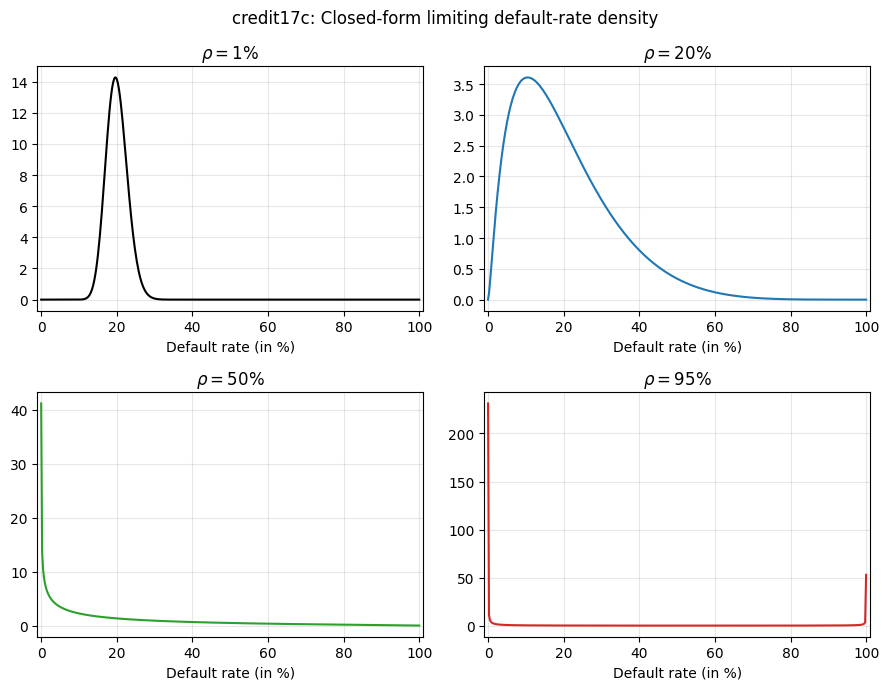

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, r, color, j in zip(axes.flat, rho_c, colors_4, range(len(rho_c))):
    ax.plot(100 * d_grid_c, pdf_c[:, j], "-", color=color, linewidth=1.5)
    ax.set_title(rf"$\rho = {100*r:.0f}\%$")
    ax.set_xlabel("Default rate (in %)")
    ax.set_xlim(-1, 101)
    ax.set_xticks(range(0, 101, 20))
    ax.grid(True, alpha=0.3)
fig.suptitle("credit17c: Closed-form limiting default-rate density")
plt.tight_layout()
plt.show()

## Cross-check: all three methods agree at `ρ=20%`

`credit17a`'s Monte Carlo histogram, `credit17b`'s exact semi-analytic
PMF (finite `n=1000`, scaled to a density by multiplying by `n`), and
`credit17c`'s closed-form `n→∞` limiting density, overlaid at their one
shared correlation level.

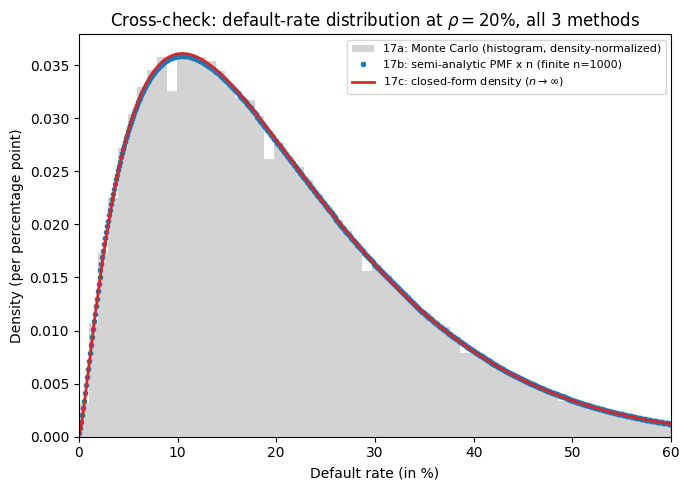

In [10]:
# Units note for this cross-check only (the individual 17a/17b/17c plots above each faithfully
# reproduce their source script's own convention of plotting density-vs-fraction-d against an
# x-axis rescaled to percent, unadjusted -- matching the .m scripts exactly). To overlay all
# three on one axis meaningfully here, everything is expressed as density-per-percentage-point:
# matplotlib's density=True already does this for the histogram (bin edges are in %), so the
# PMF/closed-form curves (both densities-per-unit-fraction-d) are divided by 100 to match.
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(100 * D_bar[:, 1], bins=bin_edges, density=True, color="lightgray", edgecolor="none",
        label="17a: Monte Carlo (histogram, density-normalized)")
ax.plot(100 * d_grid_b, n * pmf[:, 1] / 100, "o", color=color_blue, markersize=3, label="17b: semi-analytic PMF x n (finite n=1000)")
ax.plot(100 * d_grid_c, pdf_c[:, 1] / 100, "-", color=color_red, linewidth=2, label=r"17c: closed-form density ($n\to\infty$)")
ax.set_xlabel("Default rate (in %)")
ax.set_ylabel("Density (per percentage point)")
ax.set_xlim(0, 60)
ax.set_title(r"Cross-check: default-rate distribution at $\rho=20\%$, all 3 methods")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

All three curves should peak in the same location and have broadly the
same shape: the Monte Carlo histogram (finite-sample, `n=1000`) is the
noisiest but centers on the same mode as the smooth semi-analytic PMF
(exact for `n=1000`), which in turn is close to — though not identical
to, since it's the finite-`n=1000` distribution rather than the
`n→∞` limit — the closed-form density from `17c`. The small remaining gap
between `17b` (finite `n`) and `17c` (`n→∞` limit) is itself informative:
it is exactly the finite-portfolio granularity effect the limiting density
is designed to abstract away.